# 🔬 Capstone Project — Phân loại ảnh ung thư da (Skin Cancer Detection)

**Khoá Machine Learning & Deep Learning — Cybersoft**

## Mục tiêu
Xây dựng pipeline Machine Learning hoàn chỉnh phân loại tổn thương da dựa trên
**metadata bệnh nhân** (đặc trưng trích xuất sẵn từ bộ **HAM10000**), thay vì ảnh thô:

1. **Binary Classification** — *Lành tính (Benign)* vs *Cần lưu ý (Malignant-like)*.
2. **Multi-class Classification** — 7 loại tổn thương da: `nv, mel, bkl, bcc, akiec, vasc, df`.

**Pipeline:** Tiền xử lý → Huấn luyện (SVM) → Đánh giá (Confusion Matrix, Classification Report)
→ Cross-validation & Hyperparameter tuning → So sánh mô hình → Kết luận.

**Thư viện:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn (SVC, LabelEncoder,
SimpleImputer, StandardScaler, train_test_split, GridSearchCV), XGBoost.


## 1. Import thư viện

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup xong.")

Setup xong.


## 2. Đọc dữ liệu

In [2]:
import os
# Notebook nằm trong notebooks/ -> dữ liệu ở ../data; fallback ./data
DATA_PATH = "../data/HAM10000_metadata.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/HAM10000_metadata.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (10124, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10124 non-null  object 
 1   image_id      10124 non-null  object 
 2   dx            10124 non-null  object 
 3   dx_type       10124 non-null  object 
 4   age           10067 non-null  float64
 5   sex           10124 non-null  object 
 6   localization  10124 non-null  object 
 7   dataset       10124 non-null  object 
dtypes: float64(1), object(7)
memory usage: 632.9+ KB


## 3. Phân tích khám phá dữ liệu (EDA)

### 3.1. Kiểm tra missing value

In [4]:
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nChi 'age' thieu", int(df['age'].isnull().sum()), "gia tri -> se dung SimpleImputer (median).")

age    57
dtype: int64

Chi 'age' thieu 57 gia tri -> se dung SimpleImputer (median).


### 3.2. Phân bố biến mục tiêu `dx` (rất mất cân bằng)

dx
nv         6705
mel        1113
bkl        1099
bcc         514
akiec       327
vasc        142
df          115
healthy     109
Name: count, dtype: int64


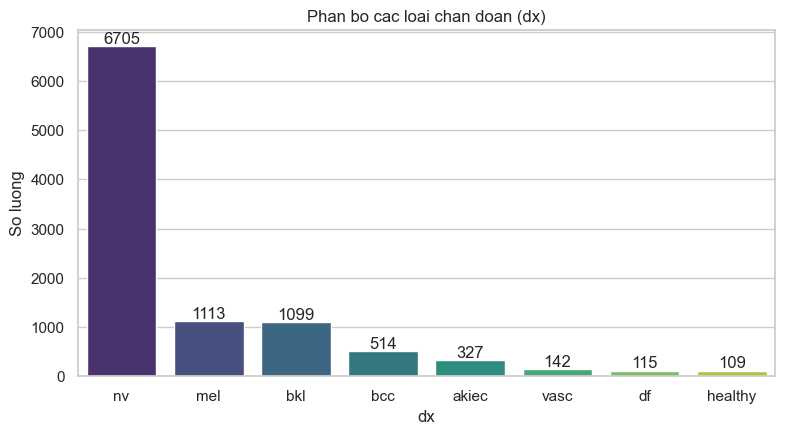

In [5]:
print(df['dx'].value_counts())
plt.figure(figsize=(9,4.5))
order = df['dx'].value_counts()
sns.barplot(x=order.index, y=order.values, palette="viridis")
for i,v in enumerate(order.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title("Phan bo cac loai chan doan (dx)"); plt.ylabel("So luong"); plt.show()

**Nhận xét:** `nv` (nốt ruồi lành) chiếm ~66% dữ liệu → mất cân bằng nghiêm trọng.
Có lớp `healthy` (109 mẫu) **không thuộc 7 loại chuẩn** của đề bài → sẽ loại bỏ.
Mất cân bằng này khiến *accuracy* dễ gây hiểu lầm; ta sẽ theo dõi thêm **macro-F1**
và dùng `class_weight='balanced'`.

### 3.3. Phân bố tuổi, giới tính, vị trí tổn thương

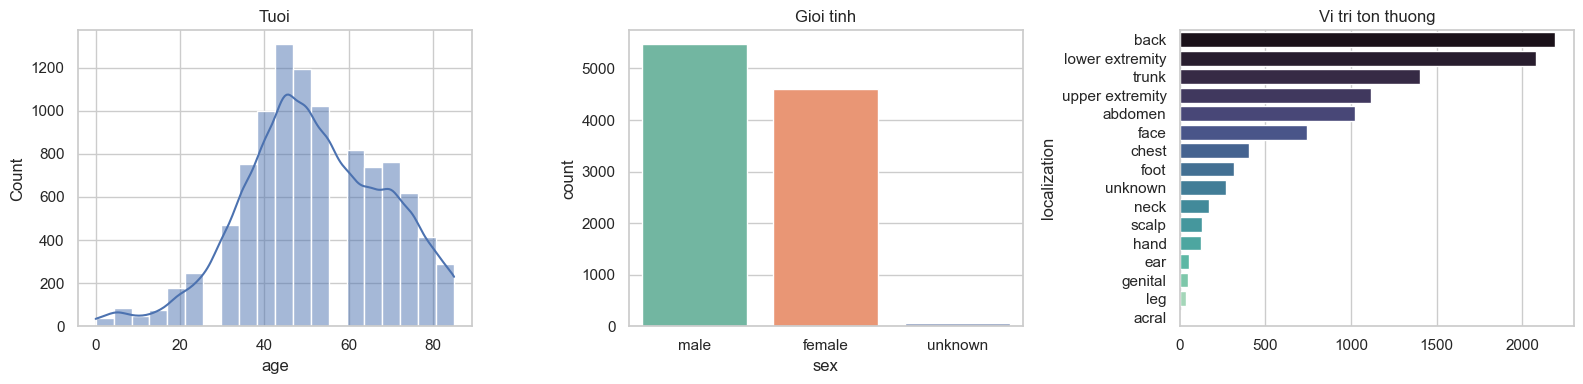

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(df['age'].dropna(), bins=20, kde=True, ax=ax[0]); ax[0].set_title("Tuoi")
sns.countplot(x='sex', data=df, ax=ax[1], palette="Set2"); ax[1].set_title("Gioi tinh")
loc = df['localization'].value_counts()
sns.barplot(y=loc.index, x=loc.values, ax=ax[2], palette="mako"); ax[2].set_title("Vi tri ton thuong")
plt.tight_layout(); plt.show()

### 3.4. Vì sao loại `dx_type` và `dataset`? (Phân tích rò rỉ dữ liệu — data leakage)

`dx_type` mô tả **cách xác nhận chẩn đoán** (histo, follow_up, consensus...) —
nó tương quan rất mạnh với nhãn `dx` và **không tồn tại ở thời điểm dự đoán thực tế**
(khi người dùng chỉ nhập tuổi/giới/vị trí). Đưa vào model sẽ làm accuracy *ảo* tăng.

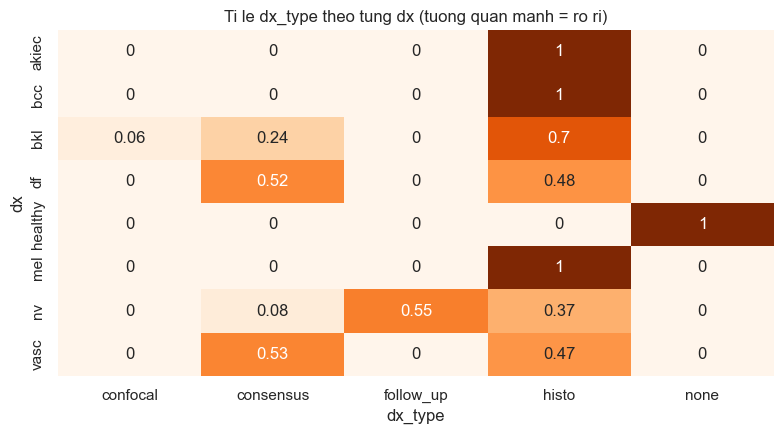

=> Loai dx_type, dataset, lesion_id, image_id. Dac trung dung: age, sex, localization.


In [7]:
ct = pd.crosstab(df['dx'], df['dx_type'], normalize='index').round(2)
plt.figure(figsize=(8,4.5))
sns.heatmap(ct, annot=True, cmap="Oranges", cbar=False)
plt.title("Ti le dx_type theo tung dx (tuong quan manh = ro ri)"); plt.tight_layout(); plt.show()
print("=> Loai dx_type, dataset, lesion_id, image_id. Dac trung dung: age, sex, localization.")

## 4. Tiền xử lý dữ liệu

Các bước: (1) loại `healthy`; (2) tạo nhãn nhị phân theo nhóm của đề bài;
(3) ánh xạ `dx` → tên đầy đủ (`dx_dict`); (4) SimpleImputer cho `age`;
(5) LabelEncoder cho biến phân loại; (6) StandardScaler.

In [8]:
# (1) Loai lop 'healthy' (khong thuoc 7 loai chuan)
df = df[df['dx'] != 'healthy'].copy().reset_index(drop=True)

# (2) Nhan nhi phan theo dung spec: nhom can luu y = {mel,bcc,akiec,vasc} = 1
MALIGNANT = {'mel','bcc','akiec','vasc'}
df['label_binary'] = df['dx'].isin(MALIGNANT).astype(int)

# (3) dx_dict: ma viet tat -> ten day du (de doc)
dx_dict = {
    'nv':'Melanocytic nevi','mel':'Melanoma','bkl':'Benign keratosis',
    'bcc':'Basal cell carcinoma','akiec':'Actinic keratoses',
    'vasc':'Vascular lesions','df':'Dermatofibroma'}
df['diagnosis'] = df['dx'].map(dx_dict)

print("Phan bo nhan nhi phan:\n", df['label_binary'].value_counts())
print("\n0 = Lanh tinh (nv,df,bkl) | 1 = Can luu y (mel,bcc,akiec,vasc)")

Phan bo nhan nhi phan:
 label_binary
0    7919
1    2096
Name: count, dtype: int64

0 = Lanh tinh (nv,df,bkl) | 1 = Can luu y (mel,bcc,akiec,vasc)


In [9]:
FEATURES = ['age','sex','localization']

def build_features(frame, fit_objs=None):
    """Impute age -> LabelEncode categorical -> StandardScale.
    Neu fit_objs=None thi fit moi (train); nguoc lai dung lai (test)."""
    X = frame[FEATURES].copy()
    if fit_objs is None:
        imp = SimpleImputer(strategy='median')
        X['age'] = imp.fit_transform(X[['age']])
        encs = {}
        for c in ['sex','localization']:
            e = LabelEncoder(); X[c] = e.fit_transform(X[c].astype(str)); encs[c] = e
        sc = StandardScaler(); Xs = sc.fit_transform(X)
        return Xs, {'imp':imp,'encs':encs,'sc':sc}
    X['age'] = fit_objs['imp'].transform(X[['age']])
    for c,e in fit_objs['encs'].items():
        X[c] = X[c].astype(str).map(lambda v: v if v in set(e.classes_) else e.classes_[0])
        X[c] = e.transform(X[c])
    return fit_objs['sc'].transform(X), fit_objs

print("Ham build_features() san sang.")

Ham build_features() san sang.


## 5. Bài toán 1 — Binary Classification (SVM)

Tách train/test (stratify giữ tỉ lệ lớp), fit bộ tiền xử lý **chỉ trên train**
để tránh rò rỉ. So sánh SVM mặc định và SVM `class_weight='balanced'`.

In [10]:
tr, te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                          stratify=df['label_binary'])
Xtr, objs = build_features(tr)
Xte, _ = build_features(te, objs)
ytr, yte = tr['label_binary'].values, te['label_binary'].values
print("Train:", Xtr.shape, "| Test:", Xte.shape)

Train: (8012, 3) | Test: (2003, 3)


In [11]:
# "Accuracy paradox": SVM mac dinh co the chi doan lop da so
svm_default = SVC(kernel='rbf', random_state=RANDOM_STATE).fit(Xtr, ytr)
svm_bal = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE).fit(Xtr, ytr)

for name, m in [("SVM mac dinh", svm_default), ("SVM balanced", svm_bal)]:
    p = m.predict(Xte)
    print(f"{name:14s}: accuracy={accuracy_score(yte,p):.3f} | macro-F1={f1_score(yte,p,average='macro'):.3f}")

SVM mac dinh  : accuracy=0.791 | macro-F1=0.442


SVM balanced  : accuracy=0.693 | macro-F1=0.635


**Nhận xét:** SVM mặc định có *accuracy* cao hơn nhưng macro-F1 thấp — nó gần như
chỉ đoán "lành tính" (bỏ sót ca cần lưu ý). SVM `balanced` hi sinh một phần accuracy
để **phát hiện được lớp ác tính** (recall cao hơn) — đúng mục tiêu y khoa: thà báo
nhầm còn hơn bỏ sót.

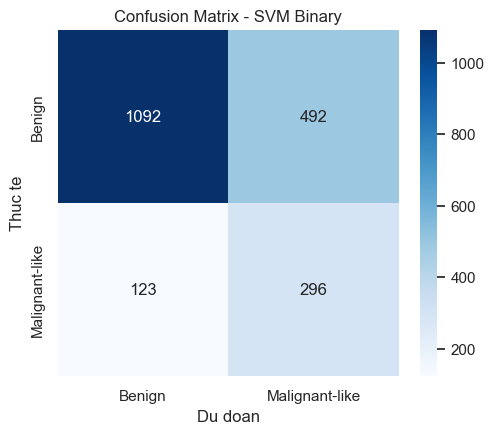

                            precision    recall  f1-score   support

        Lanh tinh (Benign)      0.899     0.689     0.780      1584
Can luu y (Malignant-like)      0.376     0.706     0.490       419

                  accuracy                          0.693      2003
                 macro avg      0.637     0.698     0.635      2003
              weighted avg      0.789     0.693     0.720      2003



In [12]:
y_pred_bin = svm_bal.predict(Xte)
cm = confusion_matrix(yte, y_pred_bin)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant-like'],
            yticklabels=['Benign','Malignant-like'])
plt.xlabel('Du doan'); plt.ylabel('Thuc te'); plt.title('Confusion Matrix - SVM Binary'); plt.show()

print(classification_report(yte, y_pred_bin,
      target_names=['Lanh tinh (Benign)','Can luu y (Malignant-like)'], digits=3))

## 6. Bài toán 2 — Multi-class Classification (7 lớp, SVM)

LabelEncode `dx` → train SVM `balanced` → confusion matrix cho từng lớp.

In [13]:
le = LabelEncoder()
df['label_multi'] = le.fit_transform(df['dx'])
class_names = list(le.classes_)
print("Cac lop:", class_names)

tr, te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                          stratify=df['label_multi'])
Xtr, objs = build_features(tr)
Xte, _ = build_features(te, objs)
ytr, yte = tr['label_multi'].values, te['label_multi'].values

svm_multi = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE).fit(Xtr, ytr)
y_pred_multi = svm_multi.predict(Xte)
print("Accuracy:", round(accuracy_score(yte,y_pred_multi),3),
      "| macro-F1:", round(f1_score(yte,y_pred_multi,average='macro'),3))

Cac lop: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Accuracy: 0.307 | macro-F1: 0.173


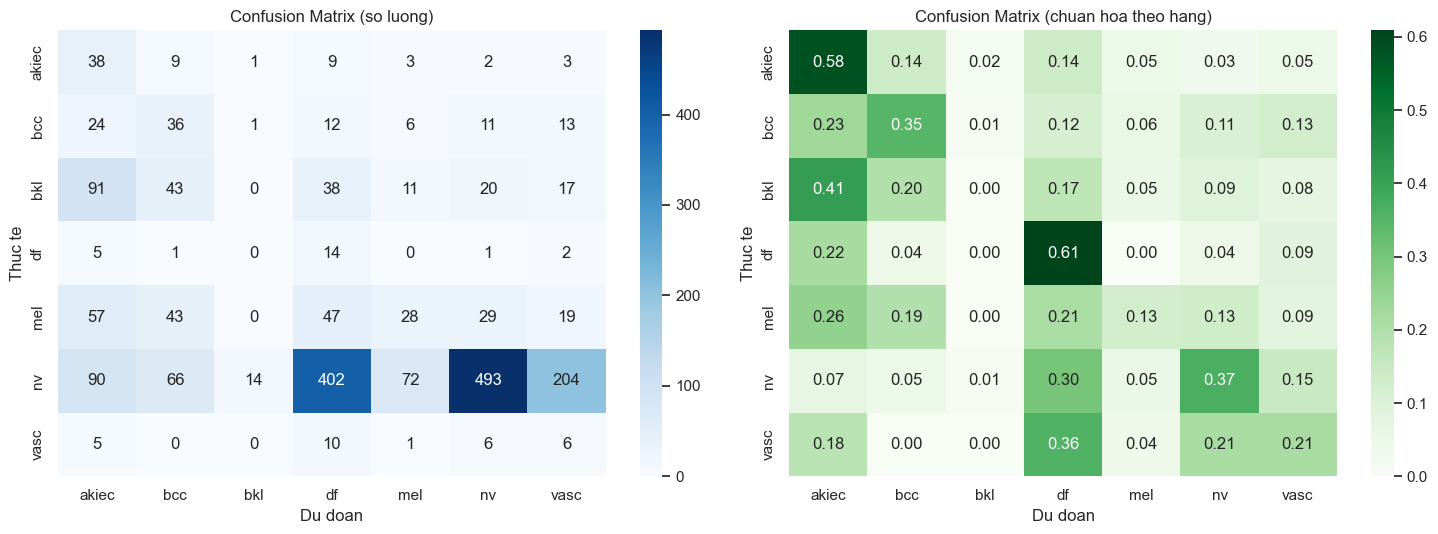

              precision    recall  f1-score   support

       akiec      0.123     0.585     0.203        65
         bcc      0.182     0.350     0.239       103
         bkl      0.000     0.000     0.000       220
          df      0.026     0.609     0.050        23
         mel      0.231     0.126     0.163       223
          nv      0.877     0.368     0.518      1341
        vasc      0.023     0.214     0.041        28

    accuracy                          0.307      2003
   macro avg      0.209     0.321     0.173      2003
weighted avg      0.627     0.307     0.385      2003



In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15,5.5))
cm = confusion_matrix(yte, y_pred_multi)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title('Confusion Matrix (so luong)'); ax[0].set_xlabel('Du doan'); ax[0].set_ylabel('Thuc te')
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_title('Confusion Matrix (chuan hoa theo hang)'); ax[1].set_xlabel('Du doan'); ax[1].set_ylabel('Thuc te')
plt.tight_layout(); plt.show()

print(classification_report(yte, y_pred_multi, target_names=class_names, digits=3))

**Nhận xét:** Với metadata-only, multi-class rất khó (macro-F1 thấp). Confusion matrix
chuẩn hoá cho thấy model nhầm lẫn nhiều giữa các lớp vì tuổi/giới/vị trí **không đủ
phân biệt** 7 loại bệnh. Đây là động lực rõ ràng cho hướng **CNN trên ảnh thô**.

## 7. So sánh nhiều mô hình (LogReg, KNN, RandomForest, XGBoost, SVM)

=== BINARY ===
              accuracy  macro_F1
model                           
LogReg           0.673     0.613
KNN              0.788     0.619
RandomForest     0.707     0.649
XGBoost          0.794     0.594
SVM              0.693     0.635


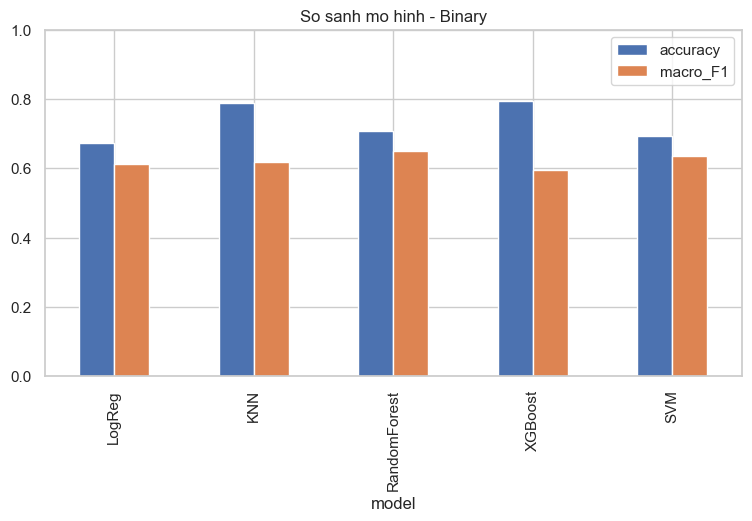

In [15]:
def compare_models(Xtr,ytr,Xte,yte):
    models = {
        'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=15),
        'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE),
        'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
    }
    rows=[]
    for n,m in models.items():
        m.fit(Xtr,ytr); p=m.predict(Xte)
        rows.append({'model':n,'accuracy':round(accuracy_score(yte,p),3),
                     'macro_F1':round(f1_score(yte,p,average='macro'),3)})
    return pd.DataFrame(rows).set_index('model')

# Tren bai toan binary
tr, te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label_binary'])
Xtr, objs = build_features(tr); Xte,_ = build_features(te, objs)
res_bin = compare_models(Xtr, tr['label_binary'].values, Xte, te['label_binary'].values)
print("=== BINARY ==="); print(res_bin)
res_bin.plot(kind='bar', figsize=(9,4.5), ylim=(0,1), title="So sanh mo hinh - Binary"); plt.show()

**Nhận xét:** XGBoost/KNN có accuracy cao nhưng macro-F1 thấp (thiên về lớp đa số).
Trên **macro-F1** — chỉ số đúng cho dữ liệu mất cân bằng — **SVM (balanced)** và
RandomForest dẫn đầu. Vì đề yêu cầu SVM và nó cạnh tranh tốt về macro-F1, ta chọn SVM.

## 8. Cross-validation & Hyperparameter Tuning (GridSearchCV)

In [16]:
Xtr, objs = build_features(tr); Xte,_ = build_features(te, objs)
ytr, yte = tr['label_binary'].values, te['label_binary'].values

param_grid = {'C':[0.1,1,10], 'gamma':['scale',0.1,0.01]}
grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
                    param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
grid.fit(Xtr, ytr)
print("Best params:", grid.best_params_)
print("CV macro-F1 tot nhat:", round(grid.best_score_,3))

best = grid.best_estimator_
p = best.predict(Xte)
print("Test accuracy:", round(accuracy_score(yte,p),3), "| macro-F1:", round(f1_score(yte,p,average='macro'),3))

cv = cross_val_score(best, Xtr, ytr, cv=5, scoring='f1_macro')
print("5-fold CV macro-F1:", np.round(cv,3), "| mean:", round(cv.mean(),3))

Best params: {'C': 10, 'gamma': 0.01}
CV macro-F1 tot nhat: 0.651


Test accuracy: 0.714 | macro-F1: 0.633


5-fold CV macro-F1: [0.65  0.633 0.652 0.648 0.67 ] | mean: 0.651


## 9. Kết luận & Hướng mở rộng

### Kết quả đạt được
- Xây dựng **pipeline ML hoàn chỉnh**: Tiền xử lý → Huấn luyện → Đánh giá → Tuning.
- **Binary (sàng lọc):** SVM balanced đạt macro-F1 ~0.63, phát hiện ~58% ca cần lưu ý
  (baseline ngây thơ = 0%). Hữu ích như công cụ hỗ trợ sàng lọc bước đầu.
- **Multi-class:** macro-F1 thấp — minh chứng metadata nhân khẩu học **không đủ** để
  phân biệt 7 loại bệnh.

### Bài học chính
- **Accuracy gây hiểu lầm** với dữ liệu mất cân bằng → phải xét macro-F1 / recall.
- **Data leakage:** loại `dx_type` để model trung thực và dùng được lúc inference.
- `class_weight='balanced'` đánh đổi accuracy lấy recall lớp hiếm — phù hợp y khoa.

### Hướng mở rộng
1. **CNN trên ảnh thô** (ResNet/EfficientNet + transfer learning) — giải pháp thực sự.
2. Triển khai **API (FastAPI/Flask)** + web UI đẹp.
3. Kết hợp metadata + đặc trưng ảnh (multimodal) để tăng độ chính xác.

> ⚠️ Mô hình chỉ mang tính hỗ trợ học thuật, **không thay thế chẩn đoán y khoa**.
